In [4]:
import torch
import matplotlib.pyplot as plt
from models.mlp import run

In [5]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [6]:
path = "./normalized_images"

# Hyperparameters
# Additionally, set test flag to True to run on test set after training, which will print the test loss and accuracy.
num_epochs = 15
lr = 1e-4
test = True
threshold = 0.6

model, train_losses, eval_losses, eval_preds, eval_labels, test_preds, test_labels = run(path, device, num_epochs=num_epochs, lr=lr, test=test, threshold=threshold)

-- MLP | Epochs: 15 | LR: 0.0001
Epoch 1/15 - Train Loss: 0.3479, Eval Loss: 0.2293
Epoch 2/15 - Train Loss: 0.2664, Eval Loss: 0.2257
Epoch 3/15 - Train Loss: 0.2446, Eval Loss: 0.2288
Epoch 4/15 - Train Loss: 0.2405, Eval Loss: 0.2132
Epoch 5/15 - Train Loss: 0.2267, Eval Loss: 0.2133
Epoch 6/15 - Train Loss: 0.2236, Eval Loss: 0.2048
Epoch 7/15 - Train Loss: 0.2267, Eval Loss: 0.2139
Epoch 8/15 - Train Loss: 0.2205, Eval Loss: 0.2048
Epoch 9/15 - Train Loss: 0.2112, Eval Loss: 0.2021
Epoch 10/15 - Train Loss: 0.2140, Eval Loss: 0.2017
Epoch 11/15 - Train Loss: 0.2133, Eval Loss: 0.2036
Epoch 12/15 - Train Loss: 0.2092, Eval Loss: 0.2066
Epoch 13/15 - Train Loss: 0.2077, Eval Loss: 0.2011
Epoch 14/15 - Train Loss: 0.2206, Eval Loss: 0.2037
Epoch 15/15 - Train Loss: 0.2057, Eval Loss: 0.2064
Training time: 196.573s
Train:
               precision    recall  f1-score   support

      NORMAL       0.90      0.97      0.94      7263
   PNEUMONIA       0.92      0.72      0.81      2737



# Training / Evaluation of MLP Classifier

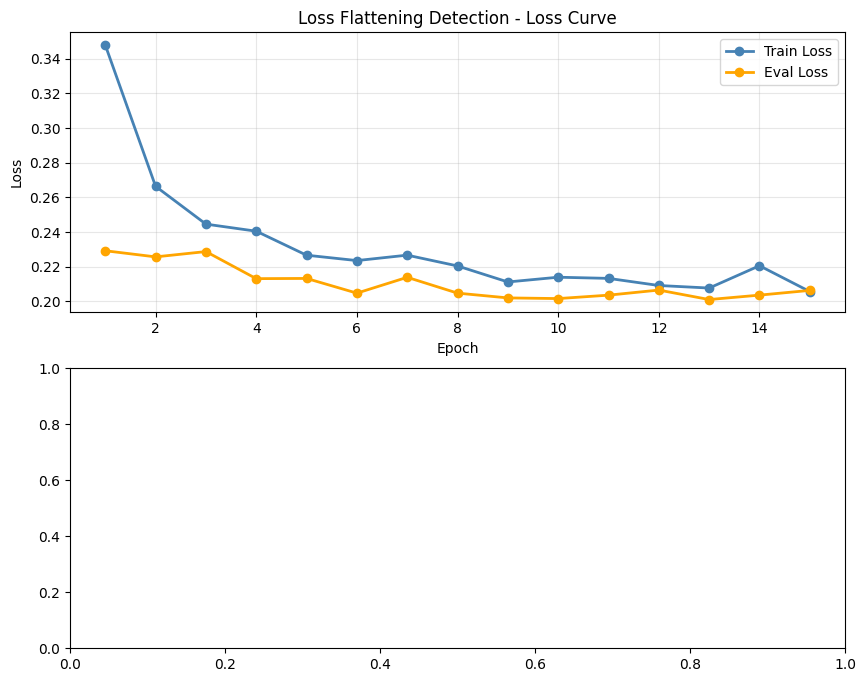


✓ Loss appears to flatten starting around epoch 7


In [7]:
from graphs import plot_loss_flattening
plot_loss_flattening(train_losses, eval_losses, window_size=2)

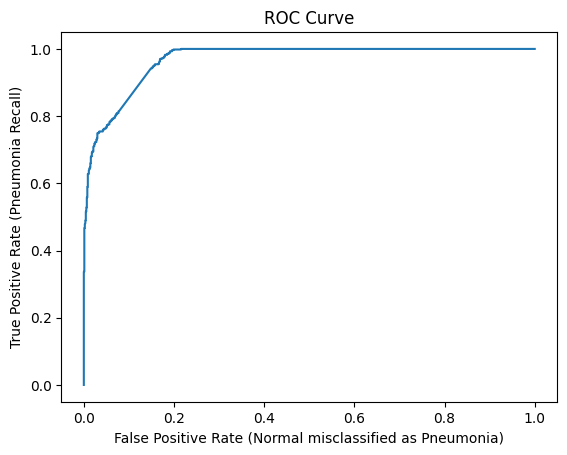

threshold=inf  pneumonia_recall=0.00  normal_misclassification_rate=0.00
threshold=1.00  pneumonia_recall=0.00  normal_misclassification_rate=0.00
threshold=0.96  pneumonia_recall=0.34  normal_misclassification_rate=0.00
threshold=0.96  pneumonia_recall=0.34  normal_misclassification_rate=0.00
threshold=0.89  pneumonia_recall=0.47  normal_misclassification_rate=0.00
threshold=0.89  pneumonia_recall=0.47  normal_misclassification_rate=0.00
threshold=0.89  pneumonia_recall=0.48  normal_misclassification_rate=0.00
threshold=0.89  pneumonia_recall=0.48  normal_misclassification_rate=0.00
threshold=0.88  pneumonia_recall=0.49  normal_misclassification_rate=0.00
threshold=0.88  pneumonia_recall=0.49  normal_misclassification_rate=0.00
threshold=0.86  pneumonia_recall=0.52  normal_misclassification_rate=0.00
threshold=0.86  pneumonia_recall=0.52  normal_misclassification_rate=0.01
threshold=0.85  pneumonia_recall=0.53  normal_misclassification_rate=0.01
threshold=0.85  pneumonia_recall=0.53  

In [8]:
from sklearn.metrics import roc_curve, RocCurveDisplay                                                               
import matplotlib.pyplot as plt                                                                                      
                                                                                                                       
# eval_preds and eval_labels come back from run()                                                                    
fpr, tpr, thresholds = roc_curve(eval_labels.astype(int), eval_preds)                                                
                                                                                                                       
plt.plot(fpr, tpr)                                                                                                   
plt.xlabel("False Positive Rate (Normal misclassified as Pneumonia)")                                                
plt.ylabel("True Positive Rate (Pneumonia Recall)")                                                                  
plt.title("ROC Curve")                                                                                               
plt.show()                                                                                                           
                                                                                                                       
# Print the tradeoff at each threshold                                                                               
for t, fp, tp in zip(thresholds, fpr, tpr):                                                                          
    print(f"threshold={t:.2f}  pneumonia_recall={tp:.2f}  normal_misclassification_rate={fp:.2f}")

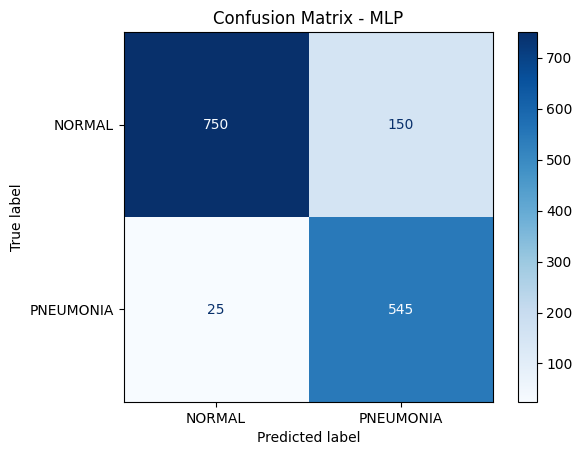

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(eval_labels, eval_preds.round(), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - MLP")
plt.show()

# Testing Results of MLP Classifier

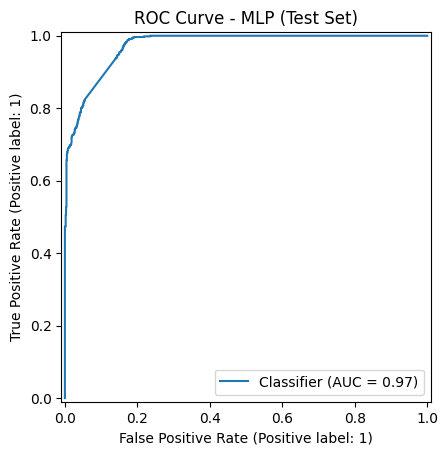

In [10]:
RocCurveDisplay.from_predictions(test_labels, test_preds)
plt.title("ROC Curve - MLP (Test Set)")
plt.show()

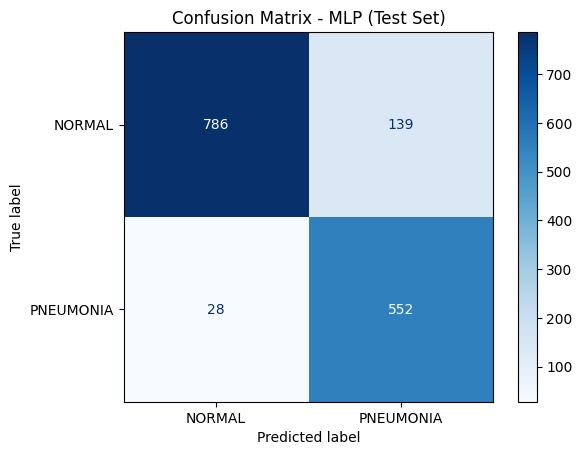

In [11]:
ConfusionMatrixDisplay.from_predictions(test_labels, test_preds.round(), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - MLP (Test Set)")
plt.show()

Test PR AUC: 0.9539
Test ROC AUC: 0.9733


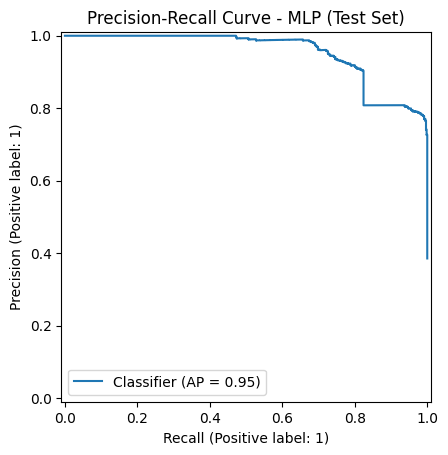

In [12]:
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.metrics import PrecisionRecallDisplay

pr_auc = average_precision_score(test_labels, test_preds)
roc_auc = roc_auc_score(test_labels, test_preds)
print(f"Test PR AUC: {pr_auc:.4f}")
print(f"Test ROC AUC: {roc_auc:.4f}")

PrecisionRecallDisplay.from_predictions(test_labels.ravel(), test_preds.ravel())
plt.title("Precision-Recall Curve - MLP (Test Set)")
plt.show()



In [13]:
import numpy as np
np.save("preds/mlp_test_preds.npy", test_preds.ravel())
np.save("preds/mlp_test_labels.npy", test_labels.ravel())

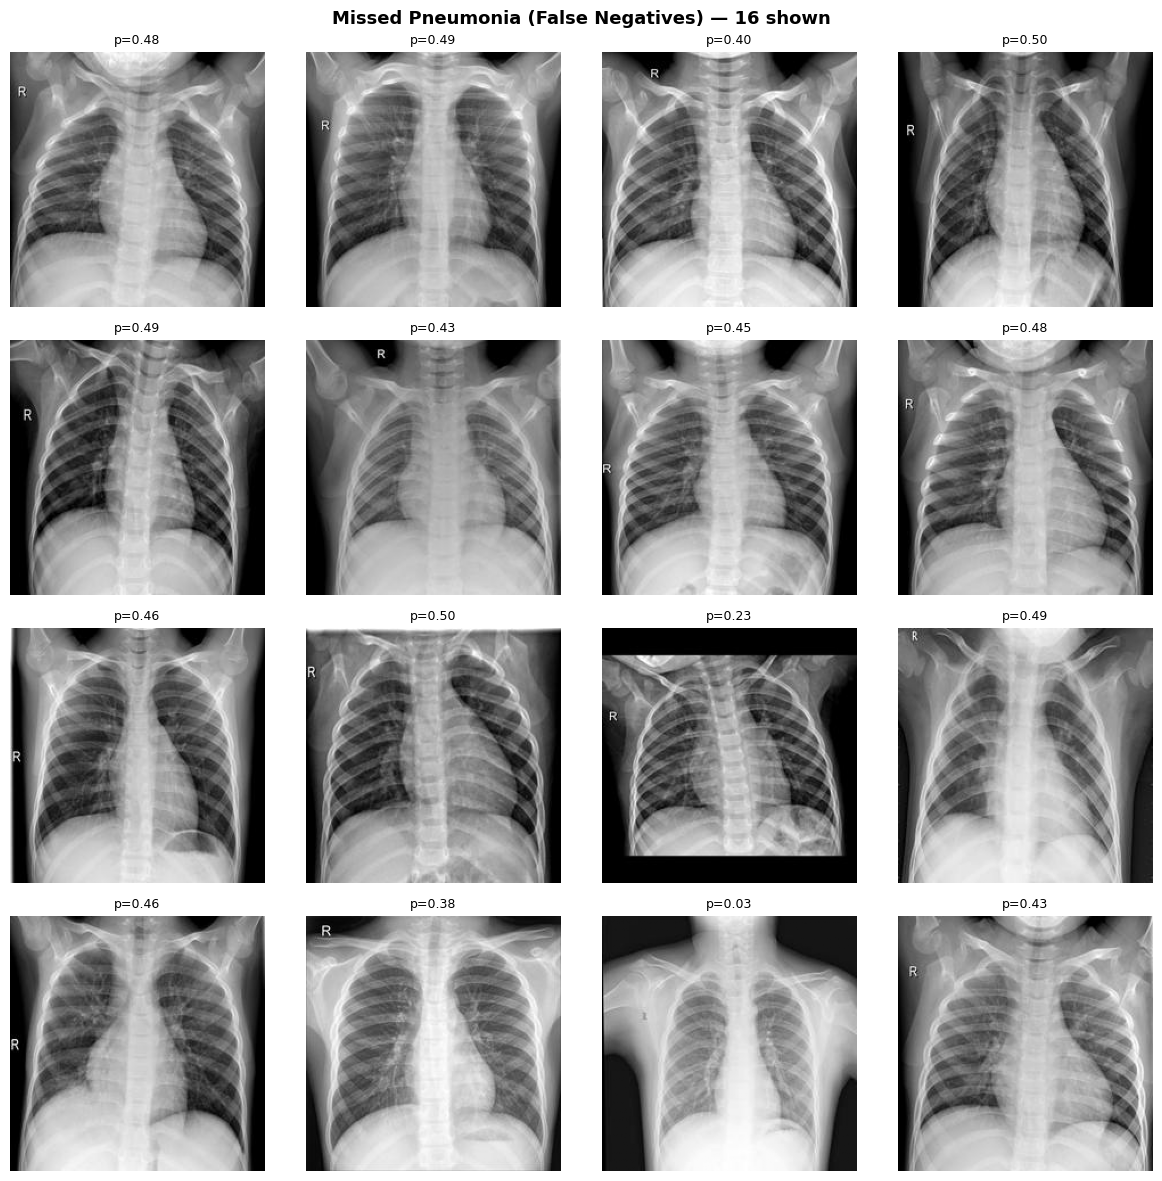

In [14]:
from graphs import show_missed_pneumonia
import importlib

import graphs
  
importlib.reload(graphs)

show_missed_pneumonia(path, test_preds, test_labels)